In [1]:
from pinballrt.dust import Dust, load, suggest_opacity_sampling
import astropy.units as u
import numpy as np

from scipy.interpolate import interp1d, interpn

In [2]:
data = np.load("../pinballrt/tests/data/diana_wice.npz")

nsamples = 4000

samples = suggest_opacity_sampling(nsamples, p_range=(2.5, 4.5), amax_range=(1.*u.micron, 10.*u.cm), n_dust_subspecies=1)

p = samples[:,0].copy()
amax = samples[:,1].copy() * u.cm

samples[:,1] = np.log10(samples[:,1])

lam = np.logspace(np.log10(data["lam"].min())+0.0001, np.log10(data["lam"].max())-0.0001, 300)*u.cm

samples = np.repeat(np.expand_dims(samples, axis=1), lam.size, axis=1)

log10_lam = np.repeat(np.expand_dims(np.log10(lam.to(u.cm).value), axis=(0,-1)), samples.shape[0], axis=0)

samples = np.concatenate((samples, log10_lam), axis=-1).reshape((-1, 3))

kabs = 10.**interpn((data["p"], np.log10(data["amax"]), np.log10(data["lam"])), np.log10(data["kabs"]), samples, method="linear")
ksca = 10.**interpn((data["p"], np.log10(data["amax"]), np.log10(data["lam"])), np.log10(data["ksca"]), samples, method="linear")

kabs = kabs.reshape((nsamples, -1))*u.cm**2/u.g
ksca = ksca.reshape((nsamples, -1))*u.cm**2/u.g

"""kabs = 10.**interp1d(np.log10(data["lam"]), np.log10(data["kabs"]), kind="linear", axis=-1)(np.log10(lam.value))*u.cm**2/u.g
ksca = 10.**interp1d(np.log10(data["lam"]), np.log10(data["ksca"]), kind="linear", axis=-1)(np.log10(lam.value))*u.cm**2/u.g

p, amax = np.meshgrid(data["p"], data["amax"], indexing="ij")
amax *= u.cm"""

# Create the Dust object.
d = Dust(lam=lam, 
         amax=amax, 
         p=p, 
         kabs=kabs,
         ksca=ksca)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type                 | Params | Mode 
-------------------------------------------------------
0 | model | MultiLayerPerceptron | 5.0 K  | train
-------------------------------------------------------
5.0 K     Trainable params
0         Non-trainable params
5.0 K     Total params
0.020     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

`Trainer.fit` stopped: `max_epochs=800` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing: |                                                                                                    …

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss         1.5256998267432209e-05
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting: |                                                                                                 …

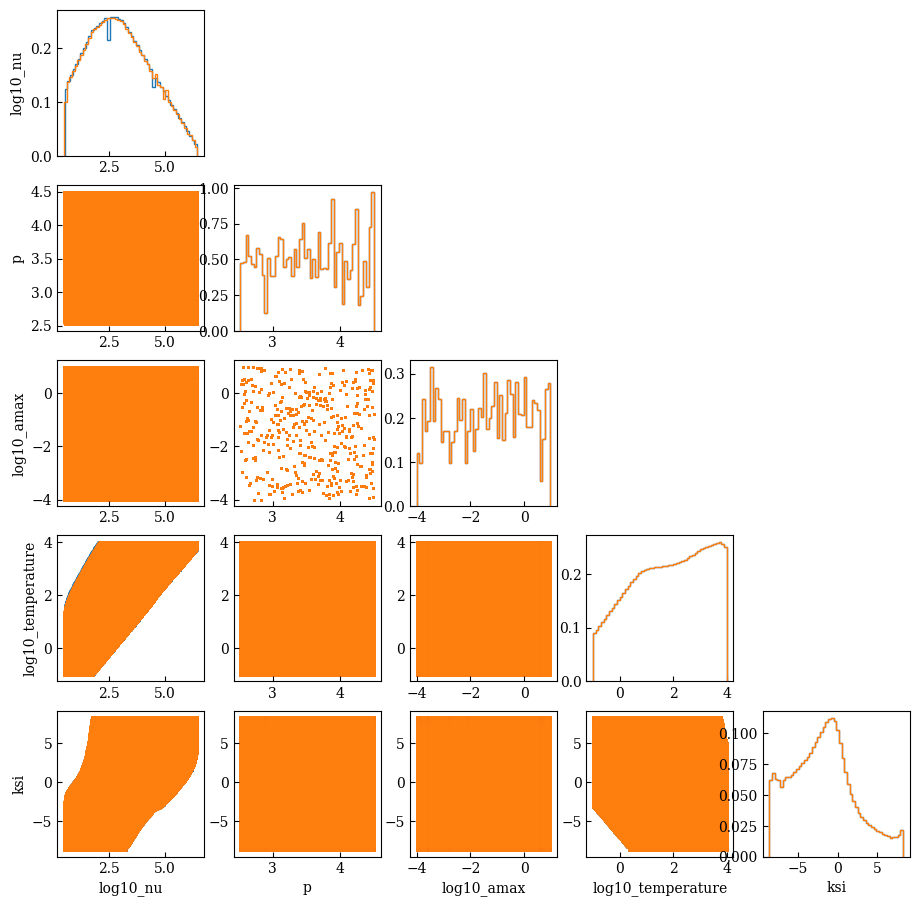

In [5]:
#for model in ["kabs", "ksca", "pmo", "random_nu"]:
for model in ["random_nu"]:
    if model in ["kabs", "ksca", "pmo"]:
        d.learn(model=model, hidden_units=(16,)*6, overwrite=True)
        batch_size = 1000
    else:
        d.learn(model=model, hidden_units=(48,)*6, overwrite=True)
        batch_size = 100000

    d.fit(epochs=800, batch_size=batch_size, num_workers=50)
    d.test_model(plot=True)

p: 4.150285326078643, amax: 0.2240181408039542, T: 296.5305719128035, abundances: []


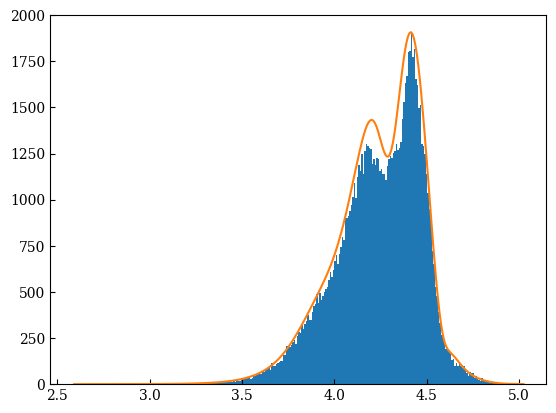

In [38]:
# Good test: p: 3.4991353911167407, amax: 1.312355072991905, T: 2008.9396240632707
# Good test: p: 4.081916099538354, amax: 0.00019792861359660814, T: 1434.7155605917776
# Good test: p: 2.807472093033742, amax: 0.00011679887614606475, T: 408.08140708872327
d.plot_random_nu_model()

In [101]:
d.save("diana_wice.dst")